# Discretization Loss Analysis
## Static Cloud Simulator — Fluid Volume LP (OPT_LP)

This notebook evaluates three price-menu discretization strategies — **Uniform**, **Geometric**, and **DP Optimal** — through the lens of the `StaticCloudSimulator`.

The allocation oracle solves a Fluid Volume LP at $t=0$ with perfect hindsight:

$$
\max_{x} \sum_j r_j x_j \quad
\text{s.t.}\quad \sum_j x_j \cdot A_{ij} \cdot D_j \leq c_i T,\ \forall i \quad
x_j \in [0,1],\ \phi_j > 0
$$

The **Global Objective Loss** is:
$$\Delta R = R^\text{cont} - R^\text{disc} = \sum_j x_j^* r_j^\text{cont} - \sum_j \tilde{x}_j^* r_j^\text{disc}$$

All cells are self-contained and reproducible with the synthetic dataset. Replace `generate_synthetic_jobs` with your real dataset CSV when available.

## Imports & Configuration

We import the simulator module and set global parameters shared across all experiments:
- **`K_BINS = 16`** — the fixed price-level count for the baseline comparison.
- **`CLUSTER_CAPACITY`** — per-resource instantaneous capacity (CPU cores, RAM units).
- **`HORIZON`** — time window $T$ in hours. The Fluid Volume budget is $c_i \cdot T$.
- **`LAMBDAS`** — equal-weight scalarization $(\lambda_1, \lambda_2, \lambda_3) = (1/3, 1/3, 1/3)$.

In [1]:
import sys, time, warnings
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import os

warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.getcwd()))

sys.path.insert(0, 'src')   # adjust if the .py lives elsewhere
import src.discretizer_simulator as discretizer_simulator
importlib.reload(discretizer_simulator)
from src.discretizer_simulator import (
    Discretizer,
    StaticCloudSimulator,
    SimulatorDiscretizer,
    generate_synthetic_jobs,
)

K_BINS   = 16
CLUSTER_CAPACITY = {'cpu': 230.0, 'ram': 130.0}
HORIZON  = 744.0          # hours (31-day month)
LAMBDAS  = (1/3, 1/3, 1/3)
V_COL, PHI_COL = 'v_rate', 'phi_rate'

COLORS = {'Uniform': '#4C72B0', 'Geometric': '#DD8452', 'DP Optimal': '#55A868'}
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

print('All imports OK')
print(f'Fluid budgets → CPU: {CLUSTER_CAPACITY["cpu"]*HORIZON:,.0f} core·h  '
      f'RAM: {CLUSTER_CAPACITY["ram"]*HORIZON:,.0f} unit·h')

All imports OK
Fluid budgets → CPU: 171,120 core·h  RAM: 96,720 unit·h


## 1. Dataset
Jobs with $\phi_j \leq 0$ violate Individual Rationality and are excluded from the LP (upper bound $x_j = 0$). 

In [3]:
data_path = os.path.join('..', 'data', 'processed', 'batch_may2019_2k.csv')
df = pd.read_csv(data_path)

# Align dataset column names to what StaticCloudSimulator.run_allocation expects
df = df.rename(columns={
    'q_j':       'priority',
    'C_elec':    'c_elec',
    'C_carbon':  'c_carbon',
    'D (hours)': 'duration',
})

n_total  = len(df)
n_ir_ok  = int((df[PHI_COL] > 0).sum())
n_ir_bad = n_total - n_ir_ok

print(f'Total jobs          : {n_total}')
print(f'IR-valid (φ > 0)    : {n_ir_ok}  ({100*n_ir_ok/n_total:.1f}%)')
print(f'IR-violated (φ ≤ 0) : {n_ir_bad}  ({100*n_ir_bad/n_total:.1f}%)')
print()

Total jobs          : 1977
IR-valid (φ > 0)    : 1381  (69.9%)
IR-violated (φ ≤ 0) : 596  (30.1%)



### 1.1 Distribution of Valuations and Virtual Values

Understanding the shape of $v$ and $\phi$ is essential: heavily right-skewed distributions (many small values, few large ones) are exactly where geometric grids should outperform uniform grids, and where the DP optimal grid is expected to make the largest relative gain.

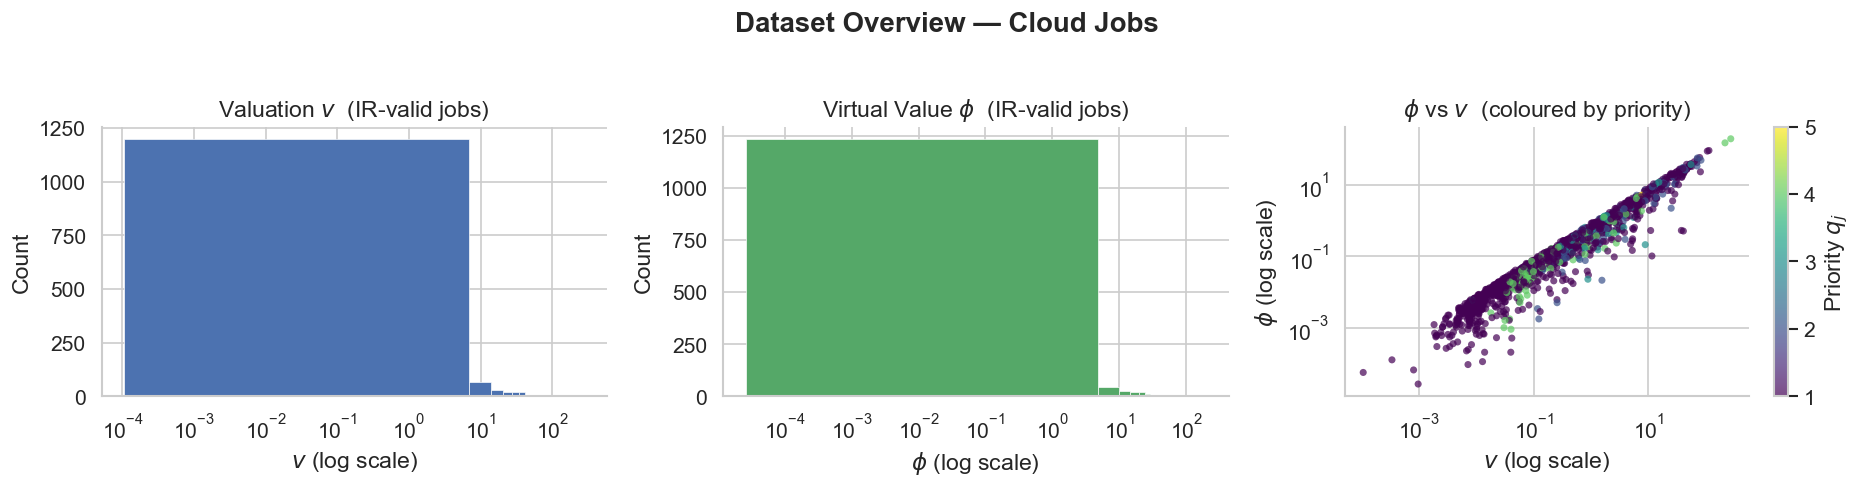

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ir_valid = df[df[PHI_COL] > 0]

axes[0].hist(ir_valid[V_COL], bins=40, color='#4C72B0', edgecolor='white', linewidth=0.4)
axes[0].set_title('Valuation $v$  (IR-valid jobs)')
axes[0].set_xlabel('$v$ (log scale)'); axes[0].set_ylabel('Count')
axes[0].set_xscale('log')

axes[1].hist(ir_valid[PHI_COL], bins=40, color='#55A868', edgecolor='white', linewidth=0.4)
axes[1].set_title('Virtual Value $\\phi$  (IR-valid jobs)')
axes[1].set_xlabel('$\\phi$ (log scale)'); axes[1].set_ylabel('Count')
axes[1].set_xscale('log')

# Scatter: v vs phi coloured by priority (dataset column q_j, renamed to priority)
sc = axes[2].scatter(ir_valid[V_COL], ir_valid[PHI_COL],
                     c=ir_valid['priority'], cmap='viridis',
                     s=18, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=axes[2], label='Priority $q_j$')
axes[2].set_title('$\\phi$ vs $v$  (coloured by priority)')
axes[2].set_xlabel('$v$ (log scale)'); axes[2].set_ylabel('$\\phi$ (log scale)')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

plt.suptitle('Dataset Overview — Cloud Jobs', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Baseline Comparison at Fixed $K = 16$

Evaluate the three grid strategies at the fixed resolution $K = 16$. For each method the Fluid LP is solved twice (continuous and discrete), and the Global Objective Loss $\Delta R$ is reported.

Key metrics returned by the simulator:
- **Total Continuous Reward** — upper bound $R^\text{cont}$ (same for all methods, as it does not depend on discretization).
- **Absolute Global Loss** — $\Delta R = R^\text{cont} - R^\text{disc}$.
- **Percentage Loss** — $\Delta R / R^\text{cont}$.
- **IR Downgrades** — jobs where the LP accepted $x_j^\text{cont} > 0$ but forced $x_j^\text{disc} = 0$ because binning pushed $\phi$ below zero.

In [8]:
sd = SimulatorDiscretizer(
    K_bins=K_BINS, capacity=CLUSTER_CAPACITY,
    horizon=HORIZON, lambdas=LAMBDAS
)
summary_df = sd.compare_all(df, v_col=V_COL, phi_col=PHI_COL, verbose=False)

display_cols = [
    'Total Continuous Reward', 'Total Discrete Reward',
    'Absolute Global Loss', 'Percentage Loss (%)',
    'Accepted Jobs (Continuous)', 'Accepted Jobs (Discrete)',
    'IR Rejected Jobs (Continuous)', 'IR Rejected Jobs (Discrete)',
    'IR Downgrades', 'Execution Time (s)',
]
display(summary_df[display_cols].T.style
        .format({
            'Uniform': '{:.3f}', 'Geometric': '{:.3f}', 'DP Optimal': '{:.3f}'
        })
        .set_caption(f'Baseline Comparison — K = {K_BINS}'))

Method,Uniform,Geometric,DP Optimal
Total Continuous Reward,3663.823,3663.823,3663.823
Total Discrete Reward,2139.748,2188.800,3189.004
Absolute Global Loss,1524.075,1475.023,474.819
Percentage Loss (%),41.598,40.259,12.960
Accepted Jobs (Continuous),1331.000,1331.000,1331.000
Accepted Jobs (Discrete),559.000,1319.000,1004.000
IR Rejected Jobs (Continuous),596.000,596.000,596.000
IR Rejected Jobs (Discrete),596.000,596.000,596.000
IR Downgrades,772.000,12.000,327.000
Execution Time (s),0.023,0.017,1.234


### 2.1 Visual: Loss and Accepted Jobs by Method

Two side-by-side bar charts: (left) Global Objective Loss in percentage terms, (right) number of jobs accepted by the discrete LP versus the continuous LP. A smaller bar on the left and taller bar on the right both indicate a better method.

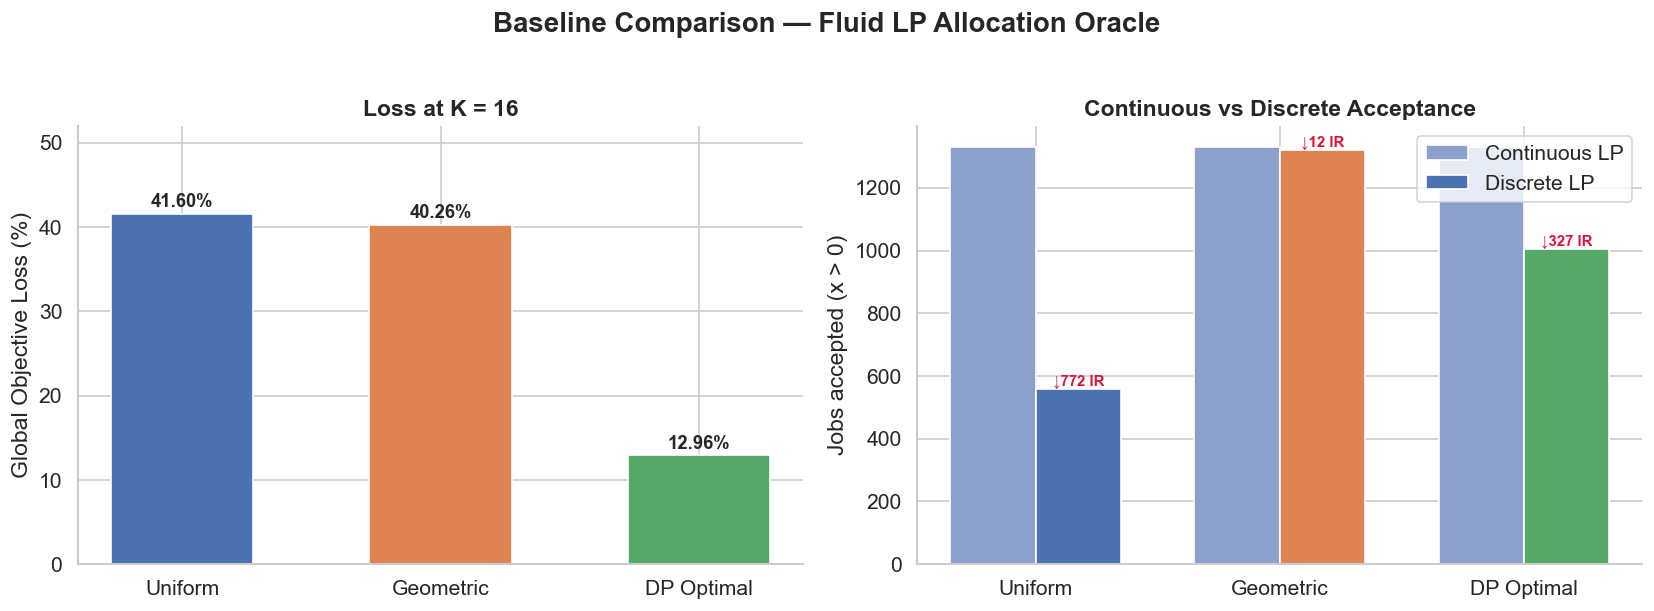

In [10]:
methods = list(summary_df.index)
loss_pct = summary_df['Percentage Loss (%)'].astype(float)
acc_cont = summary_df['Accepted Jobs (Continuous)'].astype(float)
acc_disc = summary_df['Accepted Jobs (Discrete)'].astype(float)
ir_down  = summary_df['IR Downgrades'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(methods, loss_pct, color=[COLORS[m] for m in methods],
                   edgecolor='white', width=0.55)
for bar, val in zip(bars, loss_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Global Objective Loss (%)')
axes[0].set_title(f'Loss at K = {K_BINS}', fontweight='bold')
axes[0].set_ylim(0, loss_pct.max() * 1.25)

x = np.arange(len(methods))
w = 0.35
b1 = axes[1].bar(x - w/2, acc_cont, width=w, label='Continuous LP',
                 color='#8da0cb', edgecolor='white')
b2 = axes[1].bar(x + w/2, acc_disc, width=w, label='Discrete LP',
                 color=[COLORS[m] for m in methods], edgecolor='white')
for bar, d in zip(b2, ir_down):
    if d > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1,
                     f'↓{int(d)} IR', ha='center', va='bottom', fontsize=9,
                     color='crimson', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel('Jobs accepted (x > 0)')
axes[1].set_title('Continuous vs Discrete Acceptance', fontweight='bold')
axes[1].legend()

plt.suptitle('Baseline Comparison — Fluid LP Allocation Oracle', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Convergence Analysis — Loss vs. $K$

Sweep $K$ from 2 to 64 for all three methods.

The **early-stop rule** $\delta_K < 0.1\%$ marks the point where adding one more bin yields less than 0.1 percent improvement.

In [11]:
K_SWEEP = [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 20, 24, 32, 48, 64]
EARLY_STOP_THRESH = 0.1   # %

sweep_data = {}
for method in SimulatorDiscretizer.METHODS:
    print(f'Sweeping {method} …', end=' ')
    t0 = time.perf_counter()
    sweep_data[method] = sd.sweep_k(
        df, method_name=method, k_values=K_SWEEP,
        v_col=V_COL, phi_col=PHI_COL, verbose=False,
        early_stop_threshold_pct=EARLY_STOP_THRESH,
    )
    print(f'{time.perf_counter()-t0:.2f}s')

# Compute marginal improvement δ_K = (loss[K-1] - loss[K]) / loss[K-1] * 100
for method, sw in sweep_data.items():
    pct = sw['Percentage Loss (%)'].values
    delta = np.concatenate([[np.nan], np.diff(pct) / np.abs(pct[:-1]) * -100])
    sw['delta_K_pct'] = delta
    sw['early_stop']  = (delta < EARLY_STOP_THRESH) & (~np.isnan(delta))

print('\nDone.')

Sweeping Uniform … 0.34s
Sweeping Geometric … 0.09s
Sweeping DP Optimal … 19.87s

Done.


### 3.1 Convergence Table

The table below shows, for each method and each $K$, the Global Objective Loss (%) and the marginal improvement $\delta_K$ (%). Rows where $\delta_K < 0.1\%$ are highlighted — those are the points where the early-stop rule would fire.

In [12]:
def build_convergence_table(sweep_data):
    frames = []
    for method, sw in sweep_data.items():
        tmp = sw[['Percentage Loss (%)', 'Execution Time (s)', 'delta_K_pct', 'early_stop']].copy()
        tmp.columns = [f'{method} Loss%', f'{method} Time(s)',
                       f'{method} δK%', f'{method} EarlyStop']
        frames.append(tmp)
    return pd.concat(frames, axis=1)

conv_table = build_convergence_table(sweep_data)

# Show clean summary: K, loss%, delta% per method
rows = []
for k in K_SWEEP:
    row = {'K': k}
    for method, sw in sweep_data.items():
        if k in sw.index:
            row[f'{method} Loss%']  = sw.loc[k, 'Percentage Loss (%)']
            row[f'{method} δK%']    = sw.loc[k, 'delta_K_pct']
            row[f'{method} stop'] = '✓' if sw.loc[k, 'early_stop'] else ''
    rows.append(row)

ct = pd.DataFrame(rows).set_index('K')

def highlight_stop(val):
    return 'background-color: #ffd6d6; color: #7a0b0b; font-weight: bold; text-align: center' if val == '✓' else ''

def highlight_loss(val):
    if not isinstance(val, float):
        return ''
    if val < 5:
        return 'background-color: #d1e7dd; color: #0b6623; font-weight: bold; text-align: center'
    if val < 15:
        return 'background-color: #fff3cd; color: #7a5901; font-weight: bold; text-align: center'
    return 'background-color: #f8d7da; color: #7a0b0b; font-weight: bold; text-align: center'

styled = (
    ct.style
      .format({c: '{:.2f}' for c in ct.columns if 'Loss' in c or 'δK' in c})
      .map(highlight_stop, subset=[c for c in ct.columns if 'stop' in c])
      .map(highlight_loss, subset=[c for c in ct.columns if 'Loss' in c])
      .set_properties(**{'text-align': 'center', 'font-size': '11pt'})
      .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('font-size', '12pt')]}])
      .set_caption(f'Convergence Table — Early-stop threshold δK < {EARLY_STOP_THRESH}%')
)

display(styled)

,Uniform Loss%,Uniform δK%,Uniform stop,Geometric Loss%,Geometric δK%,Geometric stop,DP Optimal Loss%,DP Optimal δK%,DP Optimal stop
K,,,,,,,,,
2,88.23,nan,,98.14,nan,,75.05,nan,
3,81.45,7.68,,89.72,8.58,,63.63,15.21,
4,74.46,8.59,,81.26,9.43,,53.71,15.59,
5,71.42,4.08,,74.22,8.66,,48.19,10.29,
6,67.27,5.82,,66.40,10.54,,33.35,30.80,
7,63.17,6.09,,61.72,7.04,,29.51,11.52,
8,57.28,9.32,,62.20,-0.78,✓,26.23,11.10,
10,53.50,6.60,,nan,nan,nan,21.80,16.89,
12,47.35,11.51,,nan,nan,nan,17.64,19.11,


### 3.2 Convergence Plots — Loss vs. $K$ (Linear & Log Scale)

Two panels show the same data on different scales:
- **Linear** — emphasises the absolute reduction and the "elbow" where gains diminish.
- **Log (y-axis)** — exposes the convergence rate; a straight line on a semi-log plot implies geometric/exponential decay in loss.

Vertical dashed lines mark the early-stop $K$ for each method.

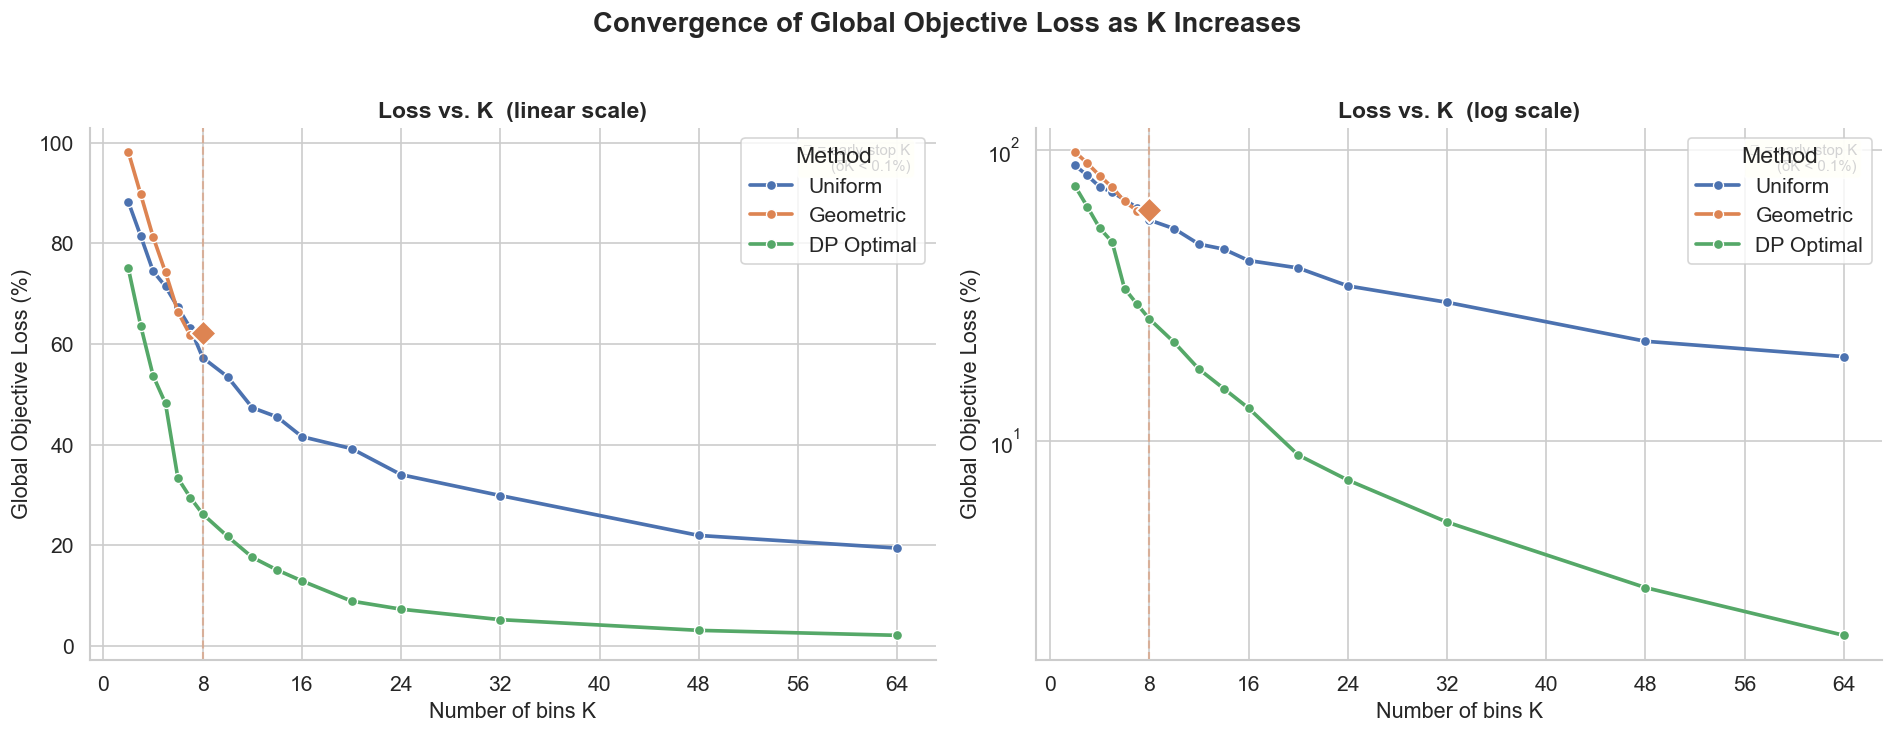

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for method, sw in sweep_data.items():
    ks   = sw.index.values
    loss = sw['Percentage Loss (%)'].values
    col  = COLORS[method]

    # early-stop K
    stop_mask = sw['early_stop'].values
    stop_ks   = ks[stop_mask]

    for ax, yscale in zip(axes, ['linear', 'log']):
        ax.plot(ks, loss, 'o-', color=col, label=method, linewidth=2.2,
                markersize=6, markeredgewidth=0.8, markeredgecolor='white')

        # mark early-stop points
        for k_stop in stop_ks:
            y_stop = sw.loc[k_stop, 'Percentage Loss (%)']
            ax.axvline(k_stop, color=col, linestyle='--', alpha=0.45, linewidth=1.3)
            ax.scatter([k_stop], [y_stop], color=col, s=120, zorder=5,
                       marker='D', edgecolors='white', linewidths=1.2)

for ax, yscale, title in zip(axes,
                              ['linear', 'log'],
                              ['Loss vs. K  (linear scale)', 'Loss vs. K  (log scale)']):
    ax.set_yscale(yscale)
    ax.set_xlabel('Number of bins K', fontsize=13)
    ax.set_ylabel('Global Objective Loss (%)', fontsize=13)
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Method')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    # annotation box
    ax.text(0.97, 0.97,
            f'◆ = early-stop K\n(δK < {EARLY_STOP_THRESH}%)',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Convergence of Global Objective Loss as K Increases', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Marginal Improvement $\delta_K$ — Identifying the Early-Stop Point

This bar chart plots $\delta_K = (L_{K-1} - L_K) / L_{K-1}$ for each method. The red dashed horizontal line is the early-stop threshold $\delta_K < 0.1\%$. Bars that dip below the threshold (shown in red) are the candidates where the algorithm would terminate the $K$ search.

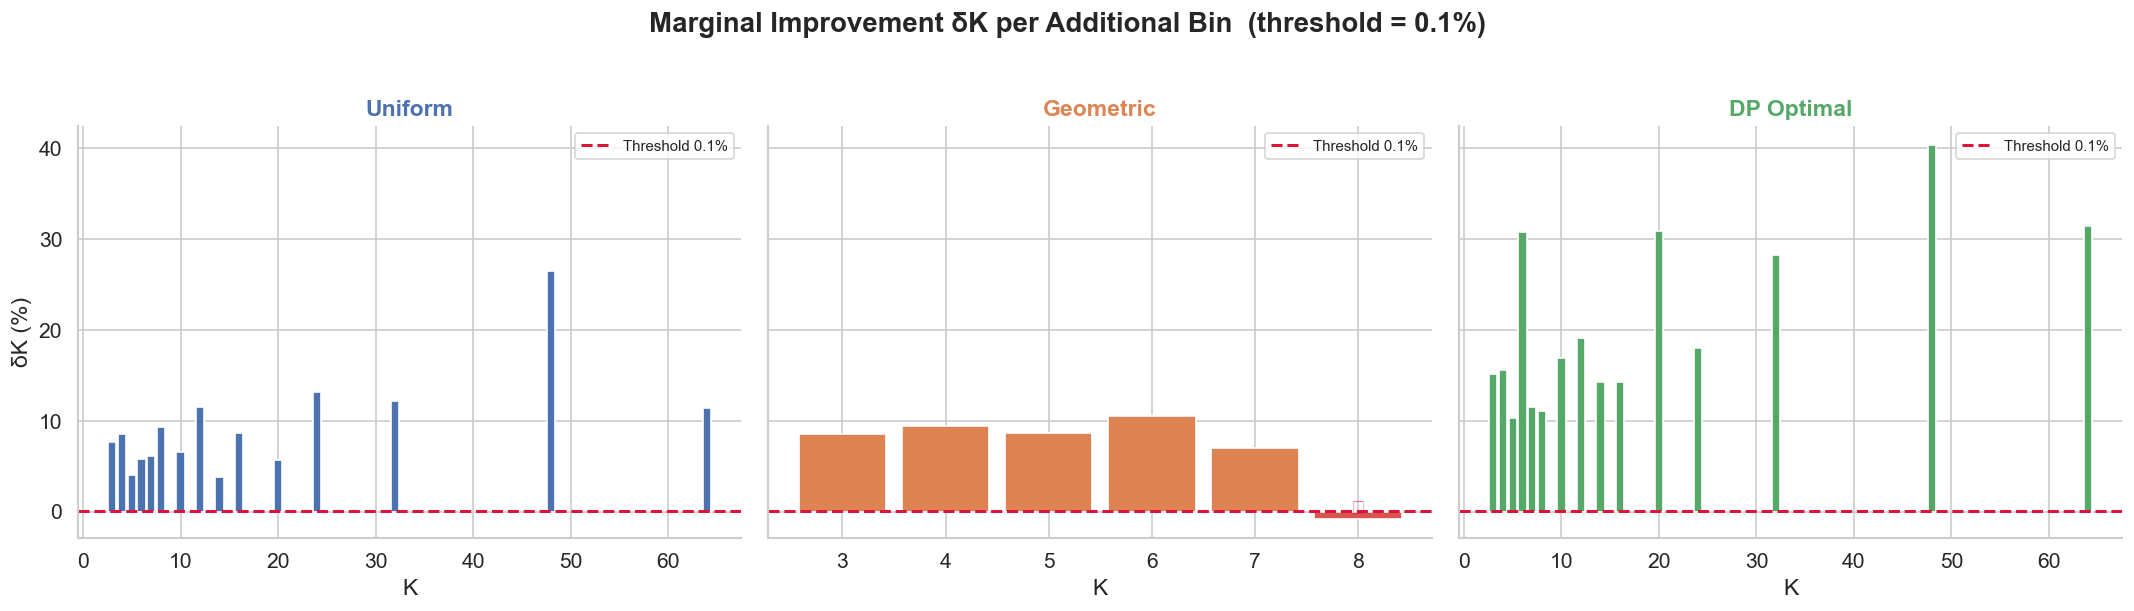

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (method, sw) in zip(axes, sweep_data.items()):
    ks    = sw.index.values[1:]   # skip K=2 (no delta)
    delta = sw['delta_K_pct'].values[1:]
    stop  = sw['early_stop'].values[1:]

    bar_colors = ['#d9534f' if s else COLORS[method] for s in stop]
    ax.bar(ks, delta, color=bar_colors, edgecolor='white', width=0.85)
    ax.axhline(EARLY_STOP_THRESH, color='crimson', linestyle='--',
               linewidth=1.8, label=f'Threshold {EARLY_STOP_THRESH}%')

    for i, (k, d, s) in enumerate(zip(ks, delta, stop)):
        if s:
            ax.text(k, d + 0.05, '✓', ha='center', va='bottom', fontsize=12,
                    color='crimson', fontweight='bold')

    ax.set_title(method, fontweight='bold', color=COLORS[method])
    ax.set_xlabel('K'); ax.set_ylabel('δK (%)') if ax == axes[0] else None
    ax.legend(fontsize=9)

plt.suptitle(
    f'Marginal Improvement δK per Additional Bin  (threshold = {EARLY_STOP_THRESH}%)',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### 3.4 Time Complexity vs. $K$

The Fluid LP solve time is essentially $O(N)$ per $K$ and does not scale with $K$ itself. However, the **DP grid fitting** is $O(K \cdot N^2)$, so its wall-clock time should grow roughly linearly in $K$. This plot verifies that empirically — it is also useful for budgeting the $K$ search in the phase-lagged test.

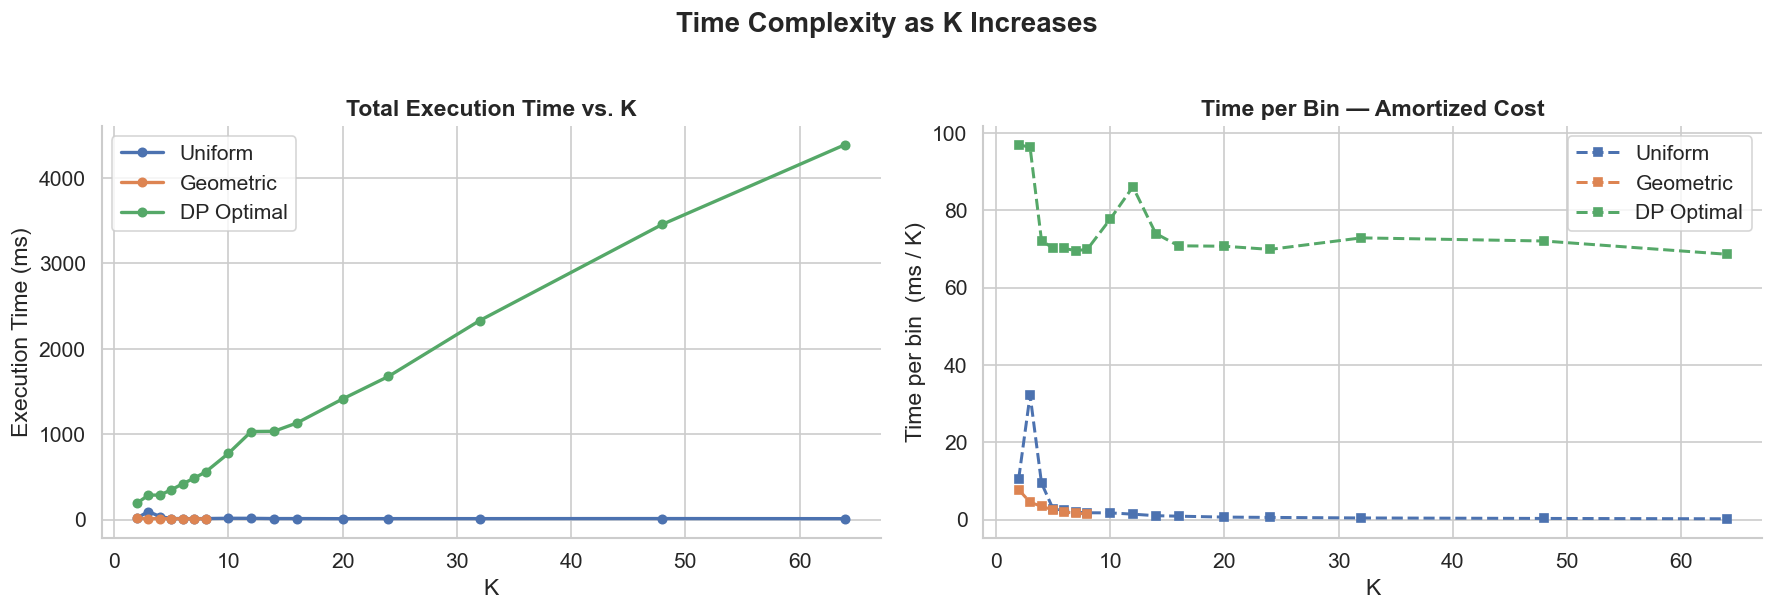

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: absolute time per method ────────────────────────────────────────────
for method, sw in sweep_data.items():
    ks  = sw.index.values
    t   = sw['Execution Time (s)'].values
    axes[0].plot(ks, t * 1000, 'o-', color=COLORS[method], label=method,
                 linewidth=2, markersize=5)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Execution Time (ms)')
axes[0].set_title('Total Execution Time vs. K', fontweight='bold')
axes[0].legend()

# ── Right: time / K (should be ~ flat for LP, linear for DP) ──────────────────
for method, sw in sweep_data.items():
    ks  = sw.index.values
    t   = sw['Execution Time (s)'].values
    axes[1].plot(ks, (t * 1000) / ks, 's--', color=COLORS[method], label=method,
                 linewidth=1.8, markersize=5)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Time per bin  (ms / K)')
axes[1].set_title('Time per Bin — Amortized Cost', fontweight='bold')
axes[1].legend()

plt.suptitle('Time Complexity as K Increases', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Per-Job Loss Analysis

We run `evaluate_method` for each baseline at $K = 16$ and extract the **job-level** results DataFrame. This contains:
- `x_cont`, `x_disc` — fractional allocation weights.
- `r_cont`, `r_disc` — per-job scalarized reward contributions.
- `loss_per_job = r_cont - r_disc`.

Analysing the distribution of `loss_per_job` reveals which jobs are most harmed by discretization.

In [16]:
job_results = {}
for method in SimulatorDiscretizer.METHODS:
    res_df, metrics = sd.evaluate_method(df, method, V_COL, PHI_COL, verbose=False)
    job_results[method] = res_df
    print(f'{method:12s}  Loss={metrics["Absolute Global Loss"]:8.3f}  '
          f'({metrics["Percentage Loss (%)"]:5.2f}%)  '
          f'IR↓={metrics["IR Downgrades"]}')

Uniform       Loss=1524.075  (41.60%)  IR↓=772
Geometric     Loss=1475.023  (40.26%)  IR↓=12
DP Optimal    Loss= 474.819  (12.96%)  IR↓=327


### 4.1 Loss Distribution per Method

Histograms and ECDFs of `loss_per_job` for accepted jobs ($x^\text{cont} > 0$). A method with most mass near zero and a thin right tail is preferable — it means most jobs suffer negligible discretization error.

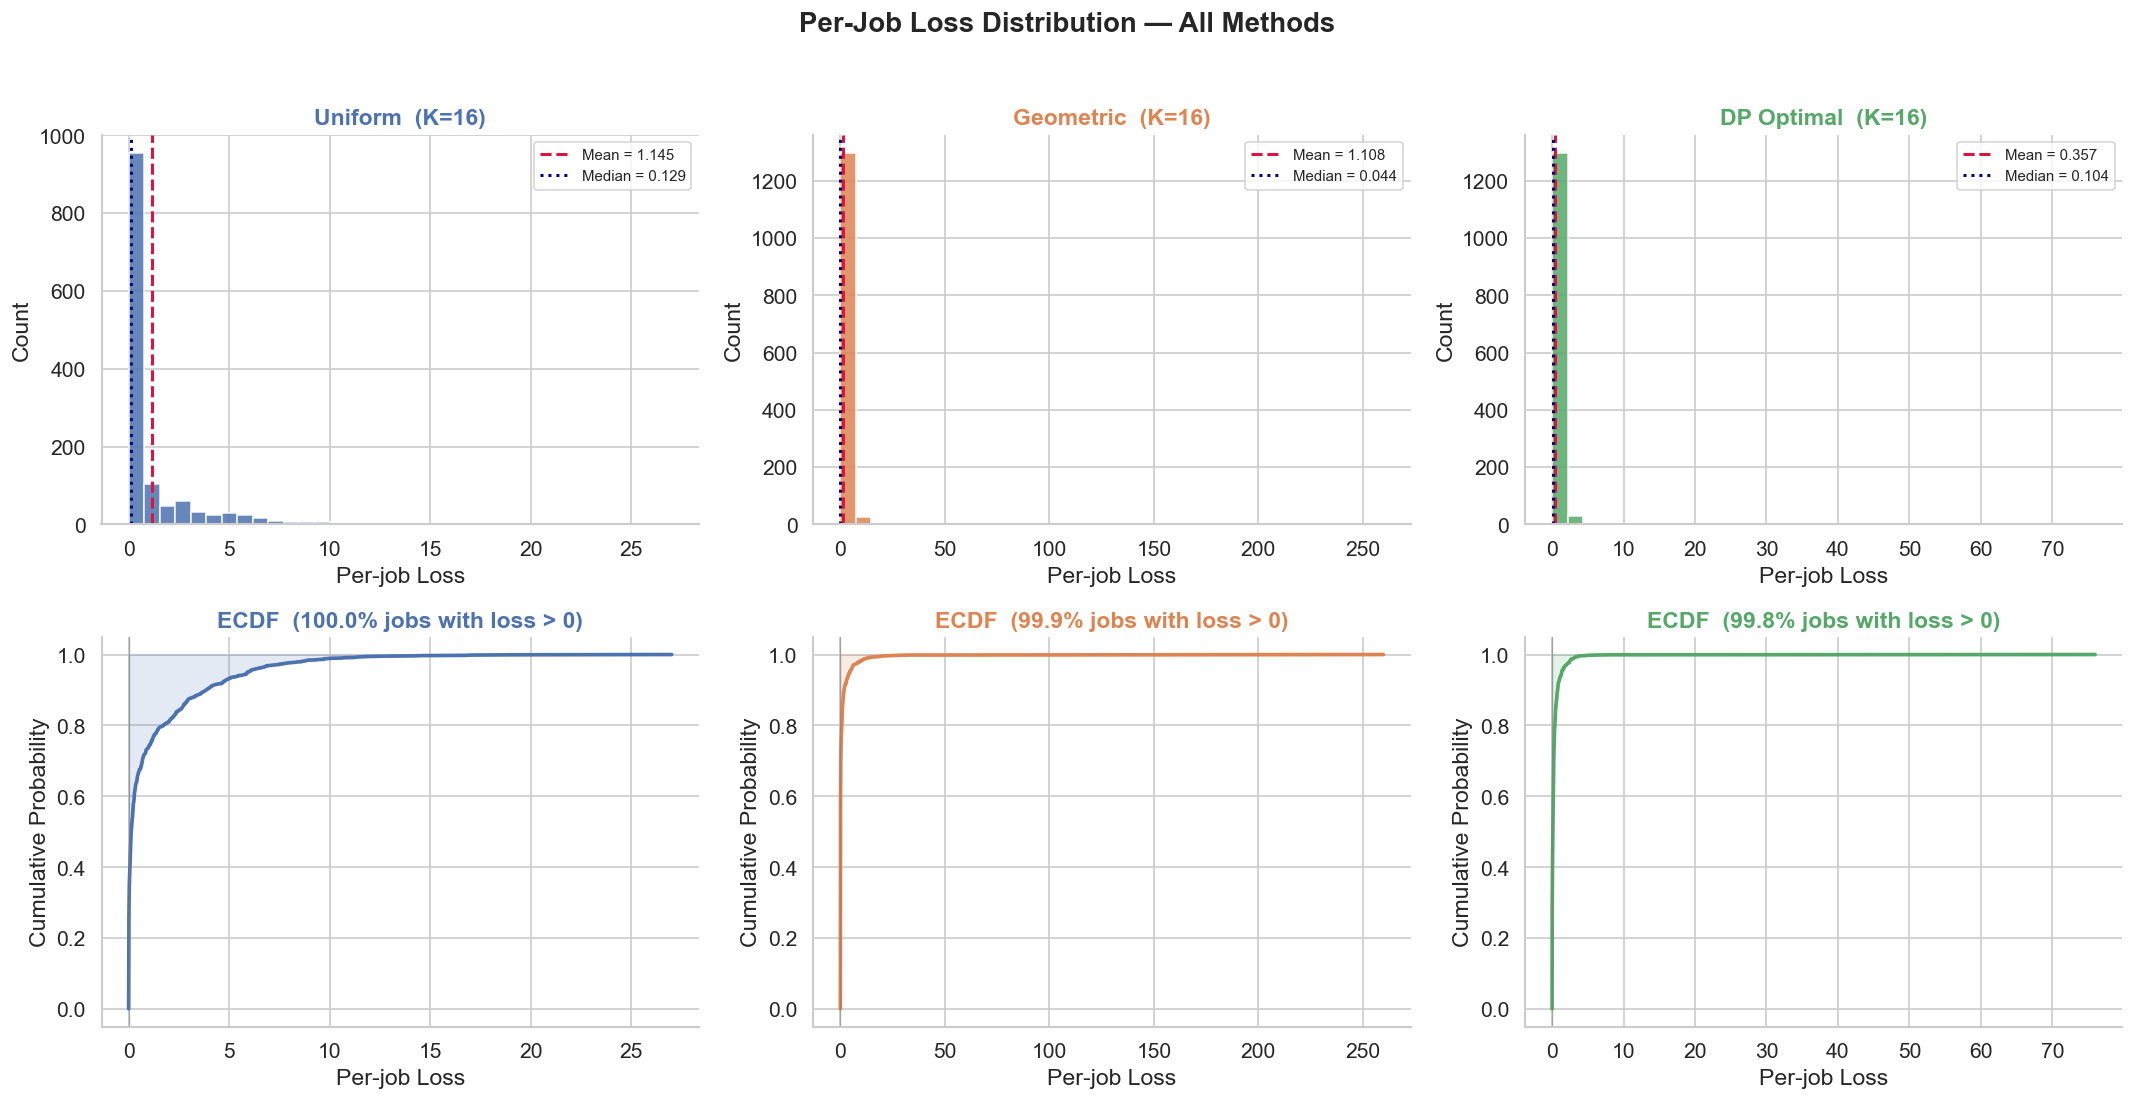

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col_idx, (method, res_df) in enumerate(job_results.items()):
    accepted = res_df[res_df['x_cont'] > 0]
    loss_vals = accepted['loss_per_job'].values
    col = COLORS[method]

    # ── histogram ──────────────────────────────────────────────────────────────
    ax_hist = axes[0, col_idx]
    ax_hist.hist(loss_vals, bins=35, color=col, edgecolor='white', alpha=0.85)
    ax_hist.axvline(loss_vals.mean(), color='crimson', linestyle='--',
                    linewidth=1.8, label=f'Mean = {loss_vals.mean():.3f}')
    ax_hist.axvline(np.median(loss_vals), color='navy', linestyle=':',
                    linewidth=1.8, label=f'Median = {np.median(loss_vals):.3f}')
    ax_hist.set_title(f'{method}  (K={K_BINS})', fontweight='bold', color=col)
    ax_hist.set_xlabel('Per-job Loss'); ax_hist.set_ylabel('Count')
    ax_hist.legend(fontsize=9)

    # ── ECDF ───────────────────────────────────────────────────────────────────
    ax_ecdf = axes[1, col_idx]
    sorted_loss = np.sort(loss_vals)
    ecdf_y = np.arange(1, len(sorted_loss)+1) / len(sorted_loss)
    ax_ecdf.plot(sorted_loss, ecdf_y, color=col, linewidth=2.2)
    ax_ecdf.axvline(0, color='grey', linestyle='-', linewidth=0.8, alpha=0.6)
    ax_ecdf.fill_betweenx(ecdf_y, sorted_loss, 0,
                          where=(sorted_loss > 0), alpha=0.15, color=col)
    pct_positive = 100 * (loss_vals > 0).mean()
    ax_ecdf.set_title(f'ECDF  ({pct_positive:.1f}% jobs with loss > 0)',
                      fontweight='bold', color=col)
    ax_ecdf.set_xlabel('Per-job Loss'); ax_ecdf.set_ylabel('Cumulative Probability')

plt.suptitle('Per-Job Loss Distribution — All Methods', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Error Distribution — Mice vs. Whales

Splits accepted jobs into **Mice** (bottom 95% by `v_rate = v / duration`) and **Whales** (top 5%) and computes the per-job average **Global Objective Loss** $\Delta r_j = r_j^\text{cont} - r_j^\text{disc}$ in each segment. A high whale/mice ratio means the method disproportionately under-prices premium jobs.

In [28]:
def mice_whale_analysis(method: str, res_df: pd.DataFrame, v_col='v_rate') -> pd.DataFrame:
    """Split accepted jobs into Mice (bottom 95%) and Whales (top 5%) by v_rate."""
    acc = res_df[res_df['x_cont'] > 0].copy()
    if len(acc) == 0:
        return pd.DataFrame()

    acc['v_rate']  = acc[v_col] / acc['duration'].clip(lower=1e-6)
    threshold      = acc['v_rate'].quantile(0.95)
    acc['segment'] = np.where(acc['v_rate'] >= threshold, 'Whale', 'Mouse')

    summary = acc.groupby('segment').agg(
        n_jobs          = ('v_rate', 'count'),
        avg_v           = (v_col, 'mean'),
        avg_v_rate      = ('v_rate', 'mean'),
        avg_global_loss = ('loss_per_job', 'mean'),
        total_loss      = ('loss_per_job', 'sum'),
    ).round(4)
    summary['method'] = method
    return summary

mw_frames = []
for method, res_df in job_results.items():
    mw = mice_whale_analysis(method, res_df, v_col=V_COL)
    if len(mw):
        mw_frames.append(mw)

mw_all = pd.concat(mw_frames)
display(mw_all.style.format({
    'avg_v': '{:.3f}', 'avg_v_rate': '{:.3f}',
    'avg_global_loss': '{:.4f}', 'total_loss': '{:.3f}'
}).set_caption('Mice vs. Whales — Per-job Average Global Objective Loss by Segment and Method'))

,n_jobs,avg_v,avg_v_rate,avg_global_loss,total_loss,method
segment,,,,,,
Mouse,1264,10.607,10.607,0.9189,1161.506,Uniform
Whale,67,1206.159,1206.159,5.4115,362.569,Uniform
Mouse,1264,10.607,10.607,0.5498,694.971,Geometric
Whale,67,1206.159,1206.159,11.6426,780.053,Geometric
Mouse,1264,10.607,10.607,0.2416,305.394,DP Optimal
Whale,67,1206.159,1206.159,2.5287,169.425,DP Optimal


### 5.1 Whale/Mice Ratio — Visualization

Two grouped bar charts: (left) average per-job Global Objective Loss $\Delta r_j$, (right) total Global Objective Loss contribution, both split by segment and method. Methods with a low Whale/Mice ratio are more equitable; a ratio $\gg 1$ means high-value jobs contribute disproportionately more to the total discretization loss.

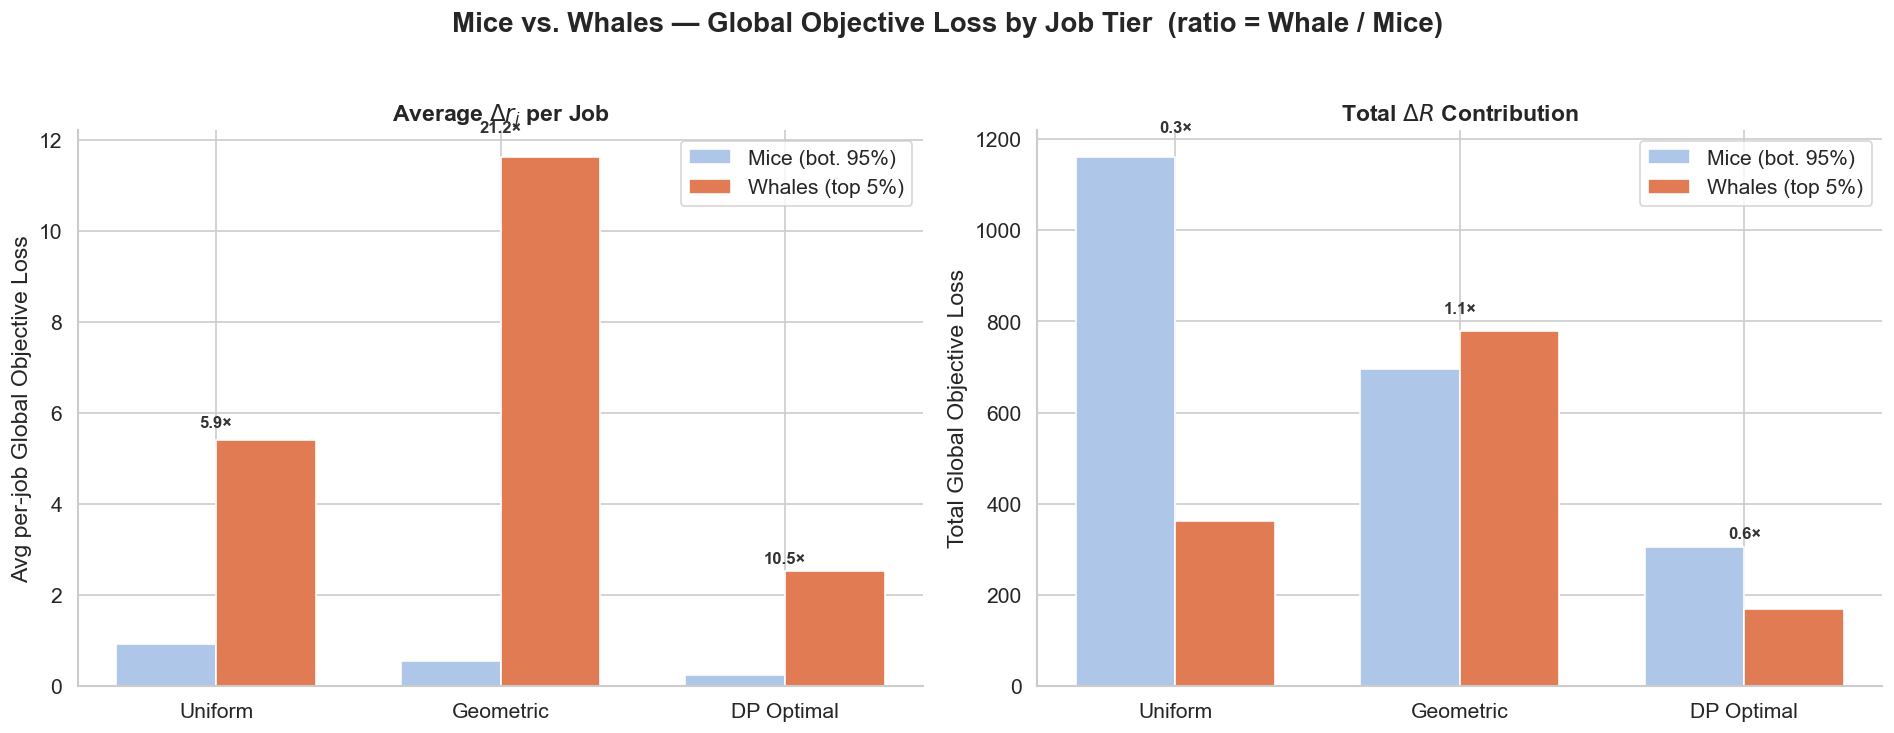

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, loss_col, ylabel, title in zip(
    axes,
    ['avg_global_loss', 'total_loss'],
    ['Avg per-job Global Objective Loss', 'Total Global Objective Loss'],
    ['Average $\\Delta r_j$ per Job', 'Total $\\Delta R$ Contribution'],
):
    methods_list = mw_all['method'].unique()
    x = np.arange(len(methods_list))
    w = 0.35

    mice_vals  = [mw_all[(mw_all['method']==m) & (mw_all.index=='Mouse')][loss_col].values
                  for m in methods_list]
    whale_vals = [mw_all[(mw_all['method']==m) & (mw_all.index=='Whale')][loss_col].values
                  for m in methods_list]

    mice_vals  = [v[0] if len(v) else 0 for v in mice_vals]
    whale_vals = [v[0] if len(v) else 0 for v in whale_vals]

    ax.bar(x - w/2, mice_vals,  width=w, label='Mice (bot. 95%)',
           color='#aec6e8', edgecolor='white')
    ax.bar(x + w/2, whale_vals, width=w, label='Whales (top 5%)',
           color='#e07b54', edgecolor='white')

    for xi, mv, wv in zip(x, mice_vals, whale_vals):
        ratio = wv / mv if mv > 0 else float('inf')
        ax.text(xi, max(mv, wv) * 1.04, f'{ratio:.1f}×',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

    ax.set_xticks(x)
    ax.set_xticklabels(methods_list)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle(
    'Mice vs. Whales — Global Objective Loss by Job Tier  (ratio = Whale / Mice)',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 6. Phase-Lagged DP Scaling Test

This experiment simulates the **real operational environment**: boundaries are fitted on Phase $M-1$ data and applied to completely unseen Phase $M$ arrivals — no data leakage in either direction.

Three strategies are compared:
1. **Fixed K = 32** — a fixed price grid, regardless of batch size.
2. **Theoretical $K^*$** — $K_m = \lceil C \cdot N^{1/5} \rceil$, calibrated in Phase 0.
3. **Optimal $K^*$ search** — sweeps $K = 2..30$ on Phase $M-1$ (50/50 internal split) and picks the argmin, capped at $K_{\text{fixed}}$.

The continuous LP reward is recomputed on the same Phase $M$ batch as the upper bound.

In [20]:
# First calibrate C independently so we can pass it in and see the value
v_all   = df[V_COL].values
phi_all = df[PHI_COL].values

print('Phase-0 calibration …')
C_calibrated = Discretizer.calibrate_C(
    v_all, phi_all,
    warmup_n=200, k_search_max=30,
    k_search_threshold_pct=1.0,
    lambda_1=1/3, lambda_2=1/3,
)
print(f'Calibrated C = {C_calibrated:.4f}')
print(f'Theoretical K formula: K* = {C_calibrated:.4f} · N^(1/5)')

Phase-0 calibration …
  [Phase-0 Calibration]  N=200  N^{1/5}=2.885  K*_empirical=20  →  C = 6.9314
Calibrated C = 6.9314
Theoretical K formula: K* = 6.9314 · N^(1/5)


In [22]:
phase_df = sd.run_phase_lagged_scaling_test(
    df,
    v_col=V_COL, phi_col=PHI_COL,
    initial_batch_size=150,
    n_phases=None,          # run until data exhausted
    K_fixed=32,
    k_search_max=30,
    k_search_threshold_pct=1.0,
    C=C_calibrated,
    lambda_1=1/3, lambda_2=1/3,
)
display(phase_df)


  Phase-Lagged DP Scaling Test — three K strategies
  Fixed K=32  |  Theoretical K*=⌈C·N^{1/5}⌉  C=6.9314
  Optimal K search (2..30, stop if improvement < 1.0%)
  Fluid LP: C_max={'cpu': 230.0, 'ram': 130.0}  T=744.0h
  λ1=0.333  λ2=0.333  λ3=0.333

  Phase 1  |  N=150  |  Cont. Reward = 557.1769
    Fixed       (K= 32):  Loss=  374.3882 (67.19%)  |  IR↓=0  acc=90  |  Time=0.0413s
    Theoretical (K= 17):  Loss=  378.1745 (67.87%)  |  IR↓=0  acc=90  |  Time=0.0243s
    Optimal K*  (K= 14):  Loss=  380.2628 (68.25%)  |  IR↓=0  acc=90  |  Search=0.0560s (converged K=14, max=30)

  Phase 2  |  N=300  |  Cont. Reward = 452.4464
    Fixed       (K= 32):  Loss=   72.2436 (15.97%)  |  IR↓=0  acc=200  |  Time=0.0780s
    Theoretical (K= 19):  Loss=   84.7131 (18.72%)  |  IR↓=5  acc=195  |  Time=0.0551s
    Optimal K*  (K= 19):  Loss=   84.7131 (18.72%)  |  IR↓=5  acc=195  |  Search=0.2007s (converged K=19, max=30)

  Phase 3  |  N=600  |  Cont. Reward = 1118.9237
    Fixed       (K= 32):  Los

,Phase,Batch_Size,Cont_Reward,K_Fixed,Loss_Fixed,Loss_Fixed_pct,IR_Down_Fixed,Accepted_Fixed,Time_Fixed_sec,K_Theo,...,Loss_Theo_pct,IR_Down_Theo,Accepted_Theo,Time_Theo_sec,K_Star,Loss_Optimal,Loss_Optimal_pct,IR_Down_Optimal,Accepted_Optimal,Time_Search_sec
0,1,150,557.176857,32,374.388204,67.193782,0,90,0.041292,17,...,67.873340,0,90,0.024266,14,380.262817,68.248136,0,90,0.056039
1,2,300,452.446378,32,72.243598,15.967328,0,200,0.077969,19,...,18.723350,5,195,0.055100,19,84.713118,18.723350,5,195,0.200689
2,3,600,1118.923671,32,317.225689,28.350968,6,411,0.163322,22,...,31.095015,26,391,0.118452,21,354.039481,31.641075,31,386,0.458894
3,4,777,1246.408282,32,162.149061,13.009305,8,527,0.341386,25,...,14.965586,19,516,0.305048,22,204.438839,16.402237,19,516,1.317441


### 6.1 Phase-Lagged Results Table

A styled summary showing, for each phase: batch size, chosen $K$ per strategy, Global Objective Loss (absolute and %), IR downgrades, and the wall-clock search time for the Optimal $K^*$ sweep. Green rows = loss below 10%; yellow = 10–20%; red = above 20%.

In [23]:
disp_cols = [
    'Phase', 'Batch_Size', 'Cont_Reward',
    'K_Fixed',  'Loss_Fixed',   'Loss_Fixed_pct',  'IR_Down_Fixed',
    'K_Theo',   'Loss_Theo',    'Loss_Theo_pct',   'IR_Down_Theo',
    'K_Star',   'Loss_Optimal', 'Loss_Optimal_pct','IR_Down_Optimal',
    'Time_Search_sec',
]

available = [c for c in disp_cols if c in phase_df.columns]

def color_loss_pct(val):
    try:
        v = float(val)
        if v < 10:  return 'background-color: #1a7a4a; color: #ffffff; font-weight: bold'
        if v < 20:  return 'background-color: #c87f0a; color: #ffffff; font-weight: bold'
        return 'background-color: #b52b2b; color: #ffffff; font-weight: bold'
    except: return ''

pct_cols = [c for c in available if 'pct' in c.lower()]

styled_phase = (
    phase_df[available].style
    .format({c: '{:.3f}' for c in available if phase_df[c].dtype == float})
    .map(color_loss_pct, subset=pct_cols)
    .set_caption('Phase-Lagged DP Scaling Test — per-phase metrics')
    .hide(axis='index')
)
display(styled_phase)


Phase,Batch_Size,Cont_Reward,K_Fixed,Loss_Fixed,Loss_Fixed_pct,IR_Down_Fixed,K_Theo,Loss_Theo,Loss_Theo_pct,IR_Down_Theo,K_Star,Loss_Optimal,Loss_Optimal_pct,IR_Down_Optimal,Time_Search_sec
1,150,557.177,32,374.388,67.194,0,17,378.175,67.873,0,14,380.263,68.248,0,0.056
2,300,452.446,32,72.244,15.967,0,19,84.713,18.723,5,19,84.713,18.723,5,0.201
3,600,1118.924,32,317.226,28.351,6,22,347.929,31.095,26,21,354.039,31.641,31,0.459
4,777,1246.408,32,162.149,13.009,8,25,186.532,14.966,19,22,204.439,16.402,19,1.317


### 6.2 Phase-Lagged Loss Trajectories

Line plots showing how the Global Objective Loss (%) evolves across phases for each of the three strategies. As the batch size doubles each phase, we expect the theoretical formula $K^* \propto N^{1/5}$ to track the fixed $K$ more closely as $N$ grows.

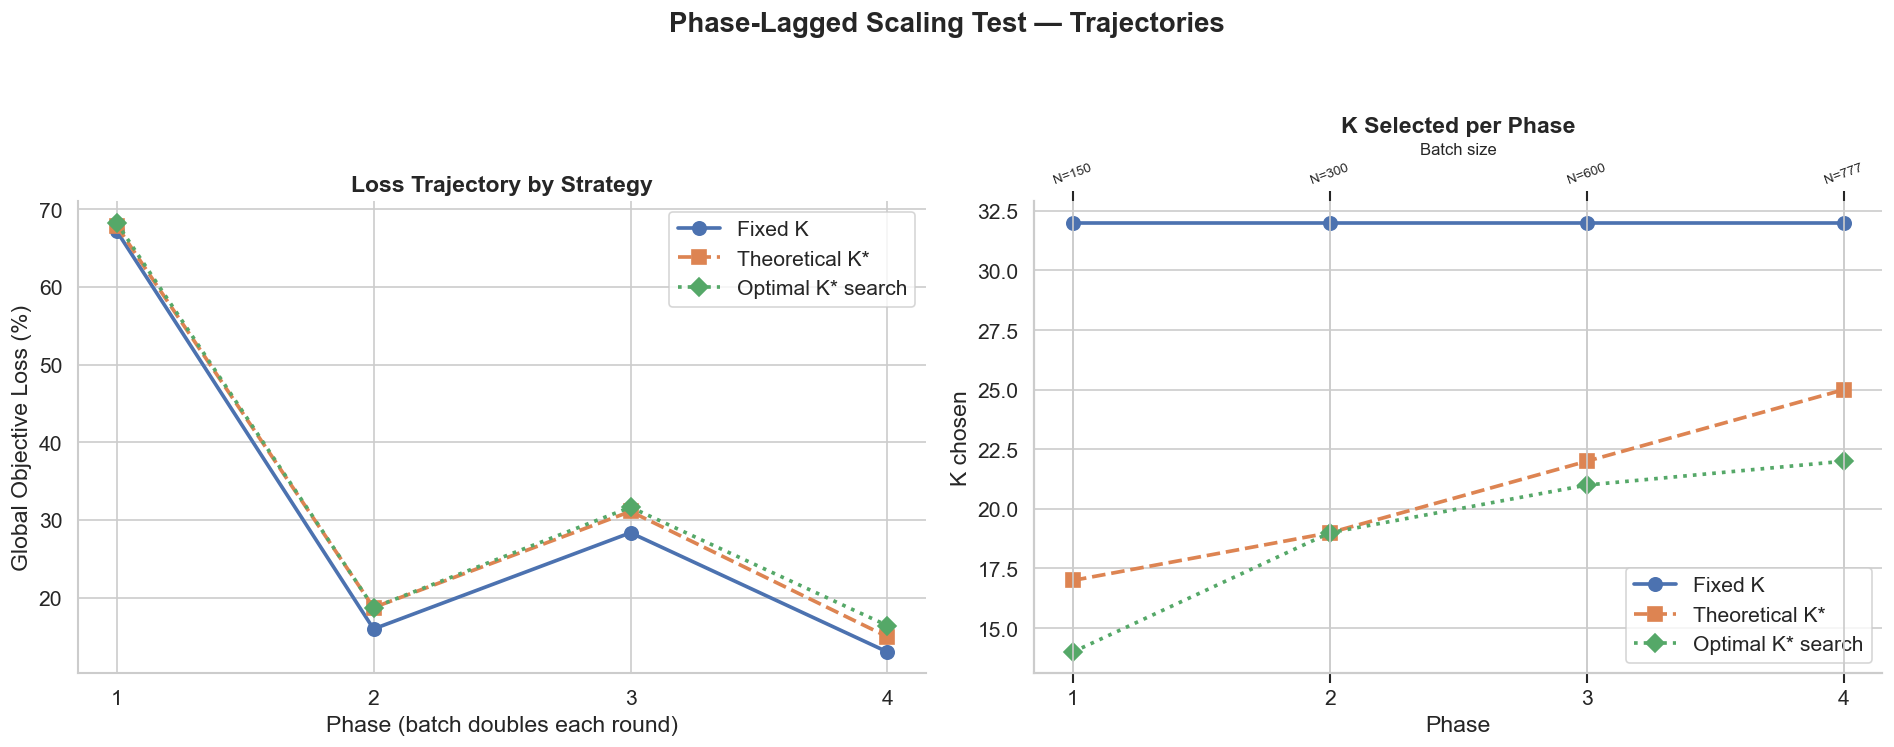

In [24]:
if len(phase_df) == 0:
    print('No phase data — increase dataset size.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    phases = phase_df['Phase'].values
    ns     = phase_df['Batch_Size'].values

    strategy_map = [
        ('Loss_Fixed_pct',   'K_Fixed',  'Fixed K',          '#4C72B0', 'o-'),
        ('Loss_Theo_pct',    'K_Theo',   'Theoretical K*',   '#DD8452', 's--'),
        ('Loss_Optimal_pct', 'K_Star',   'Optimal K* search','#55A868', 'D:'),
    ]

    # ── Left: loss % vs phase ──────────────────────────────────────────────────
    for loss_col, k_col, label, col, ls in strategy_map:
        if loss_col in phase_df.columns:
            axes[0].plot(phases, phase_df[loss_col], ls, color=col,
                         label=label, linewidth=2.2, markersize=8)
    axes[0].set_xlabel('Phase (batch doubles each round)')
    axes[0].set_ylabel('Global Objective Loss (%)')
    axes[0].set_title('Loss Trajectory by Strategy', fontweight='bold')
    axes[0].set_xticks(phases)
    axes[0].legend()

    # ── Right: chosen K vs phase ───────────────────────────────────────────────
    for loss_col, k_col, label, col, ls in strategy_map:
        if k_col in phase_df.columns:
            axes[1].plot(phases, phase_df[k_col], ls, color=col,
                         label=label, linewidth=2.2, markersize=8)

    # secondary x-axis showing N
    ax2 = axes[1].twiny()
    ax2.set_xlim(axes[1].get_xlim())
    ax2.set_xticks(phases)
    ax2.set_xticklabels([f'N={n:,}' for n in ns], fontsize=8, rotation=20)
    ax2.set_xlabel('Batch size', fontsize=10)

    axes[1].set_xlabel('Phase')
    axes[1].set_ylabel('K chosen')
    axes[1].set_title('K Selected per Phase', fontweight='bold')
    axes[1].set_xticks(phases)
    axes[1].legend(loc='lower right')

    plt.suptitle('Phase-Lagged Scaling Test — Trajectories', fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.show()

### 6.3 Search Time vs. Loss Trade-off

Scatter plot: y-axis = Global Loss (%) achieved, x-axis = wall-clock search time (ms). Points on the bottom-left are best (low loss, fast). This helps decide whether the Optimal $K^*$ search is worth its computational overhead compared to using the closed-form Theoretical $K^*$.

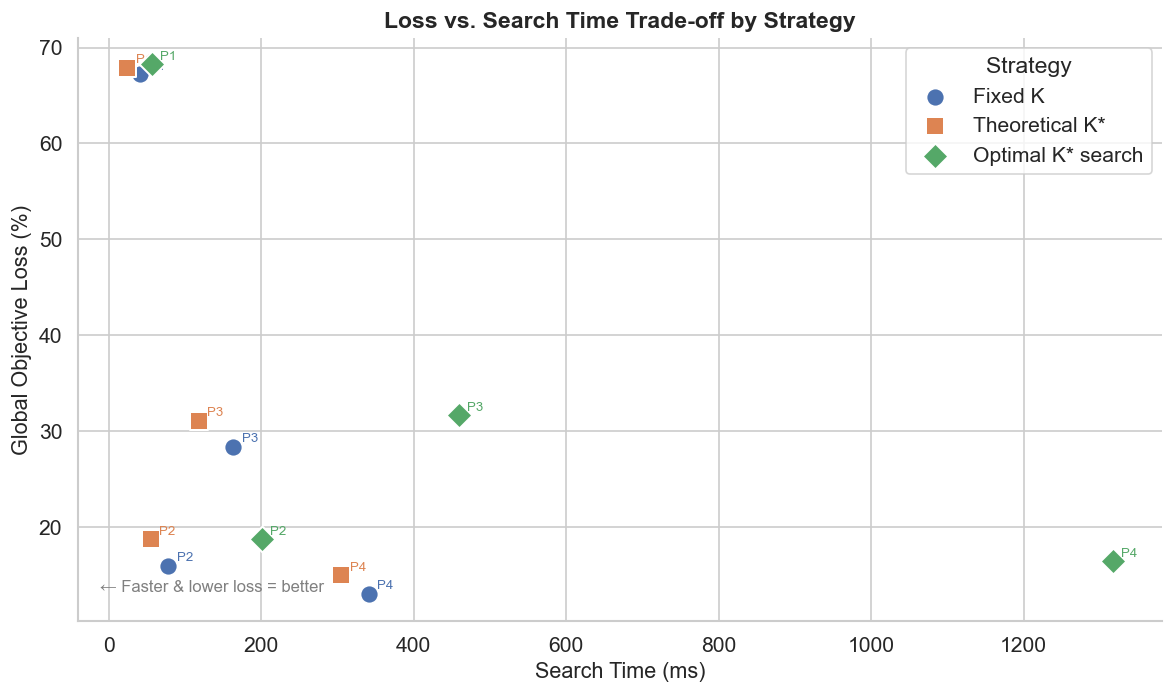

In [25]:
if len(phase_df) == 0:
    print('No phase data.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    for loss_col, time_col, label, col, marker in [
        ('Loss_Fixed_pct',   'Time_Fixed_sec',  'Fixed K',           '#4C72B0', 'o'),
        ('Loss_Theo_pct',    'Time_Theo_sec',   'Theoretical K*',    '#DD8452', 's'),
        ('Loss_Optimal_pct', 'Time_Search_sec', 'Optimal K* search', '#55A868', 'D'),
    ]:
        if loss_col in phase_df.columns and time_col in phase_df.columns:
            x_vals = phase_df[time_col].values * 1000  # ms
            y_vals = phase_df[loss_col].values
            ax.scatter(x_vals, y_vals, s=120, color=col, marker=marker,
                       label=label, zorder=3, edgecolors='white', linewidths=1.2)
            # annotate phase number
            for ph, xv, yv in zip(phase_df['Phase'].values, x_vals, y_vals):
                ax.annotate(f'P{ph}', (xv, yv), textcoords='offset points',
                            xytext=(5, 3), fontsize=8, color=col)

    ax.set_xlabel('Search Time (ms)', fontsize=13)
    ax.set_ylabel('Global Objective Loss (%)', fontsize=13)
    ax.set_title('Loss vs. Search Time Trade-off by Strategy', fontweight='bold')
    ax.legend(title='Strategy')

    # ideal region annotation
    ax.text(0.02, 0.05, '← Faster & lower loss = better',
            transform=ax.transAxes, fontsize=10, color='grey')

    plt.tight_layout()
    plt.show()

## 7. Summary Dashboard

A consolidated view of all key findings: method ranking by loss at $K=16$, the early-stop $K$ per method from the convergence sweep, and the total loss across all phases in the phase-lagged test.

This cell produces the final "one-page" summary table suitable for a report or presentation.

In [27]:
rows = []
for method in SimulatorDiscretizer.METHODS:
    sw = sweep_data[method]

    # Early-stop K (first K where δK < threshold; None if never triggered)
    stop_ks = sw.index[sw['early_stop']].tolist()
    early_k = stop_ks[0] if stop_ks else 'Never'

    # Loss at K=32
    loss_at_32 = sw.loc[32, 'Percentage Loss (%)'] if 32 in sw.index else float('nan')

    # Loss at K=64
    loss_at_64 = sw.loc[64, 'Percentage Loss (%)'] if 64 in sw.index else float('nan')

    # Total phase-lagged loss for fixed-K strategy (if available)
    pl_fixed_pct = phase_df['Loss_Fixed_pct'].mean() if len(phase_df) else float('nan')

    rows.append({
        'Method':              method,
        'Loss at K=32 (%)':    round(float(loss_at_32), 2),
        'Loss at K=64 (%)':    round(float(loss_at_64), 2),
        'Early-Stop K':        early_k,
        'IR Downgrades (K=32)':int(summary_df.loc[method, 'IR Downgrades']),
    })

summary_final = pd.DataFrame(rows).set_index('Method')

# Phase totals
if len(phase_df) > 0:
    total_cont = phase_df['Cont_Reward'].sum()
    for strategy, loss_col, label in [
        ('Fixed K',         'Loss_Fixed',   'Fixed K'),
        ('Theoretical K*',  'Loss_Theo',    'Theoretical K*'),
        ('Optimal K* srch', 'Loss_Optimal', 'Optimal K* search'),
    ]:
        if loss_col in phase_df.columns:
            tl = phase_df[loss_col].sum()
            print(f'Phase-Lagged Total Loss | {label:20s}: {tl:8.3f}  '
                  f'({100*tl/total_cont:.2f}% of total cont. reward)')

print()
display(
    summary_final.style
    .format({'Loss at K=32 (%)': '{:.2f}', 'Loss at K=64 (%)': '{:.2f}'})
    .background_gradient(subset=['Loss at K=32 (%)'], cmap='RdYlGn_r')
    .background_gradient(subset=['Loss at K=64 (%)'], cmap='RdYlGn_r')
    .set_caption('Final Summary — All Methods')
)

Phase-Lagged Total Loss | Fixed K             :  926.007  (27.44% of total cont. reward)
Phase-Lagged Total Loss | Theoretical K*      :  997.349  (29.55% of total cont. reward)
Phase-Lagged Total Loss | Optimal K* search   : 1023.454  (30.32% of total cont. reward)



,Loss at K=32 (%),Loss at K=64 (%),Early-Stop K,IR Downgrades (K=32)
Method,,,,
Uniform,29.90,19.47,Never,772
Geometric,nan,nan,8,12
DP Optimal,5.27,2.15,Never,327
